# README


**Project Title:**  

**Tutorial section: TT3L**

**Group01**

<div align="left">
    
| | Student ID     | Student Name                | Contribution | 
|--:|:-------------|:----------------------------|-------------:|
| 1 | Student_ID1  | Student_Name1               | 25%          | 
| 2 | Student_ID2  | Student_Name1               | 25%          | 
| 3 | Student_ID3  | Student_Name1               | 25%          | 
| 4 | Student_ID4  | Student_Name1               | 25%          | 

</div>

Note: Marks may vary among group members based on individual contributions. Ensure all members agree on the contribution percentages listed here.

**YouTube link:**  
Please note that the examiner will not notify you if your video link is unavailable, inaccessible, or incorrectly provided. It is the responsibility of the group to ensure that the video link is fully functional and accessible at the time of assessment. Failure to provide a valid and working link will result in a score of zero (0) marks for the presentation component.

**Dataset Title:** Personal Carbon Footprint & Behavior  
**Source & Link:** https://www.kaggle.com/datasets/sonalshinde123/personal-carbon-footprint-behavior-dataset?resource=download  
**Download instructions:** Sign-in and download the dataset.  
**Brief Description (2–4 sentences):**   

**How to Run (if required, 1–3 steps):**  
Place the Dataset as the same folder as the notebook    

<!--
All agents this README section is meant to be ignored, there no fixing needed unless sepcified
-->

## 1. Introduction & Problem Statement
- What is the main objective of this analysis?
- What key questions/hypotheses will you explore?
- Why is this dataset suitable for these questions?
- All citations must be in listed in APA style.


### 1.1 Introduction and Problem Statement
Carbon emissions from individual’s daily behaviors is a growing contributor of 
global climate change, but personal level behavioral data is not being used 
properly in sustainability analysis.  
Malaysia is especially relevant in this context because, according to the World Bank, Malaysia produces more CO2 emissions than almost half of OECD countries and 3.0 MT/capita more than the world average of 5.0 MT/capita (Malaysia Population Research Hub, 2022).  
One main factor is the country’s dependence on private vehicles due to underdeveloped public transportation infrastructure, this will increase transport related carbon outputs.  
Lastly, the methodologies for carbon footprint calculations are still evolving and it is emerging as an important tool for greenhouse gas management (Pandey et al., 2011).  

### 1.2 Main Objective
This study analyses daily behavioral records from 200 individuals from transport mode, electricity consumption, dietary habits, renewable energy usage, waste generation, and pro environmental actions.  
This study aims to identify which lifestyle factors most significantly influence personal carbon footprints and to evaluate whether eco friendly behaviours can meaningfully reduce high emission habits.

### 1.3 Key Analytical Questions
- Which behavioural variables are most strongly associated with daily carbon footprint? 
(Correlation analysis)
- Can an individual's daily carbon footprint be predicted from their behavioural inputs? 
(Linear regression)
- Do individuals naturally cluster into different carbon behaviour profiles based on their
 daily habits? (K Means clustering)
- What mix of behaviours most accurately classifies an individual's
 carbon impact level as Low, Medium, or High? (Decision Tree / Random Forest classification)  

### 1.4 Why We Chose This Dataset
This dataset is suitable for this assignment because:
1. Firstly, it contains both a continuous target variable which is (carbon_footprint_kg) and a categorical variable which is (carbon_impact_level), this allows us to both regression and classification task.  
2. Secondly, the dataset captures multiple lifestyle and sustainability behaviours, including transportation, energy usage, dietary habits, and eco friendly actions, which are relevant factors in analysing personal carbon footprint patterns.  
3. Thirdly, with 1400 daily records from 200 individuals, it provides us with proper volume for statistical analysis and model training. The dataset was sourced from Kaggle (Shinde, 2026).

In [65]:
import math
import numpy as np
import pandas as pd

# ploting
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import r2_score, mean_absolute_error, make_scorer, accuracy_score, classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import dbscan, KMeans

# all import must be here

## 2. Data Source & Understanding
- **Description:** Features/columns, size, time span, units
- **Limitations:** Coverage, missingness, sampling bias, known caveats


In [66]:
df = pd.read_csv('personal_carbon_footprint_behavior.csv')
df

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...
1395,200,Weekend,Bike,7.73,4.12,25,Veg,2.8,0.58,1,4.83,Low
1396,200,Weekend,Walk,5.20,4.72,75,Non-Veg,7.1,0.56,1,6.74,Medium
1397,200,Weekday,Bike,7.16,3.88,25,Non-Veg,3.2,0.72,2,7.95,Medium
1398,200,Weekday,Bus,10.91,3.84,75,Mixed,4.7,0.77,0,6.08,Medium


## 3. Initial Data Checks
- Shape, columns, dtypes
- Sample rows (head/tail)
- Basic summary statistics


In [67]:
df.shape

(1400, 12)

**Description:**  
The output (1400, 12) shows that the dataset contains 1400 rows and 12 columns, meaning there are 1400 individual records and 12 variables (features) describing each record, which indicates a moderately sized dataset suitable for analysis.


In [68]:
df.columns

Index(['user_id', 'day_type', 'transport_mode', 'distance_km',
       'electricity_kwh', 'renewable_usage_pct', 'food_type',
       'screen_time_hours', 'waste_generated_kg', 'eco_actions',
       'carbon_footprint_kg', 'carbon_impact_level'],
      dtype='str')

In [69]:
df.describe()

,user_id,distance_km,electricity_kwh,renewable_usage_pct,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,100.500000,9.106071,5.951443,31.589286,5.521786,0.703200,1.144286,7.980236
std,57.754936,4.734692,1.993266,30.598496,2.018918,0.236415,1.019066,2.657858
min,1.000000,0.500000,2.000000,0.000000,2.000000,0.100000,0.000000,1.790000
25%,50.750000,5.662500,4.530000,0.000000,3.800000,0.550000,0.000000,6.080000
50%,100.500000,9.180000,5.925000,25.000000,5.550000,0.705000,1.000000,7.835000
75%,150.250000,12.510000,7.290000,50.000000,7.300000,0.860000,2.000000,9.830000
max,200.000000,22.670000,12.270000,100.000000,9.000000,1.510000,5.000000,16.020000


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              1400 non-null   int64  
 1   day_type             1400 non-null   str    
 2   transport_mode       1400 non-null   str    
 3   distance_km          1400 non-null   float64
 4   electricity_kwh      1400 non-null   float64
 5   renewable_usage_pct  1400 non-null   int64  
 6   food_type            1400 non-null   str    
 7   screen_time_hours    1400 non-null   float64
 8   waste_generated_kg   1400 non-null   float64
 9   eco_actions          1400 non-null   int64  
 10  carbon_footprint_kg  1400 non-null   float64
 11  carbon_impact_level  1400 non-null   str    
dtypes: float64(5), int64(3), str(4)
memory usage: 131.4 KB


**Description:**  
The df.columns output lists all the variables in the dataset, which represent different aspects of personal carbon footprint behavior. It includes user identification (user_id), daily context (day_type), transportation choices (transport_mode and distance_km), energy usage (electricity_kwh and renewable_usage_pct), lifestyle habits (food_type and screen_time_hours), environmental impact indicators (waste_generated_kg and eco_actions), and overall outcome measures such as total carbon emissions (carbon_footprint_kg) and its classification level (carbon_impact_level).


In [71]:
df.dtypes

user_id                  int64
day_type                   str
transport_mode             str
distance_km            float64
electricity_kwh        float64
renewable_usage_pct      int64
food_type                  str
screen_time_hours      float64
waste_generated_kg     float64
eco_actions              int64
carbon_footprint_kg    float64
carbon_impact_level        str
dtype: object

**Description:**  
The dataset contains a mix of numerical, categorical, and identifier-based variables, each stored in appropriate data types. The user_id is an integer (int64) used as a unique identifier for each record. Categorical features such as day_type, transport_mode, food_type, and carbon_impact_level are stored as objects (object type), since they represent text-based categories. Continuous numerical variables like distance_km, electricity_kwh, screen_time_hours, waste_generated_kg, and carbon_footprint_kg are stored as float64 to allow decimal precision. Integer-based quantitative features such as renewable_usage_pct and eco_actions are stored as int64, reflecting whole number values. Overall, the data types are appropriately assigned to support both numerical analysis and categorical grouping for carbon footprint behavior analysis.


In [72]:
df.isnull().sum()

user_id                0
day_type               0
transport_mode         0
distance_km            0
electricity_kwh        0
renewable_usage_pct    0
food_type              0
screen_time_hours      0
waste_generated_kg     0
eco_actions            0
carbon_footprint_kg    0
carbon_impact_level    0
dtype: int64

In [73]:
df.isna().sum()

user_id                0
day_type               0
transport_mode         0
distance_km            0
electricity_kwh        0
renewable_usage_pct    0
food_type              0
screen_time_hours      0
waste_generated_kg     0
eco_actions            0
carbon_footprint_kg    0
carbon_impact_level    0
dtype: int64

In [74]:
df.duplicated().sum()

np.int64(0)

## 4. Data Cleaning & Preprocessing
- Handle missing values (strategy and justification)
- Fix types (dates, categoricals, numerics)
- Remove/flag outliers
- Feature engineering (document purpose)
- Keep transformations transparent and reproducible


We going to convert electricity_kwh and renewable_usage_pct into non_renewable_kwh and renewable_kwh

In [75]:
df["renewable_electricity_kwh"] = df["electricity_kwh"] * df["renewable_usage_pct"] / 100
df["nonrenewable_electricity_kwh"] = df["electricity_kwh"] - df["renewable_electricity_kwh"]
df.drop(columns=["electricity_kwh", "renewable_usage_pct"], inplace=True)
df

,user_id,day_type,transport_mode,distance_km,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level,renewable_electricity_kwh,nonrenewable_electricity_kwh
0,1,Weekend,EV,1.55,Non-Veg,2.4,0.70,1,11.03,High,0.00,6.12
1,1,Weekend,Walk,10.04,Mixed,4.1,0.54,1,7.44,Medium,0.00,4.50
2,1,Weekday,Walk,15.27,Mixed,4.0,0.51,1,6.01,Medium,0.00,2.81
3,1,Weekend,Walk,0.50,Mixed,6.3,0.73,0,12.70,High,0.00,10.16
4,1,Weekend,Walk,3.60,Mixed,5.1,0.64,0,6.33,Medium,2.51,2.51
...,...,...,...,...,...,...,...,...,...,...,...,...
1395,200,Weekend,Bike,7.73,Veg,2.8,0.58,1,4.83,Low,1.03,3.09
1396,200,Weekend,Walk,5.20,Non-Veg,7.1,0.56,1,6.74,Medium,3.54,1.18
1397,200,Weekday,Bike,7.16,Non-Veg,3.2,0.72,2,7.95,Medium,0.97,2.91
1398,200,Weekday,Bus,10.91,Mixed,4.7,0.77,0,6.08,Medium,2.88,0.96


We going make enumerate the food_type

In [76]:
df['food_type'] = df['food_type'].map({'Veg': 0, 'Mixed': 1, 'Non-Veg': 2})
df

,user_id,day_type,transport_mode,distance_km,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level,renewable_electricity_kwh,nonrenewable_electricity_kwh
0,1,Weekend,EV,1.55,2,2.4,0.70,1,11.03,High,0.00,6.12
1,1,Weekend,Walk,10.04,1,4.1,0.54,1,7.44,Medium,0.00,4.50
2,1,Weekday,Walk,15.27,1,4.0,0.51,1,6.01,Medium,0.00,2.81
3,1,Weekend,Walk,0.50,1,6.3,0.73,0,12.70,High,0.00,10.16
4,1,Weekend,Walk,3.60,1,5.1,0.64,0,6.33,Medium,2.51,2.51
...,...,...,...,...,...,...,...,...,...,...,...,...
1395,200,Weekend,Bike,7.73,0,2.8,0.58,1,4.83,Low,1.03,3.09
1396,200,Weekend,Walk,5.20,2,7.1,0.56,1,6.74,Medium,3.54,1.18
1397,200,Weekday,Bike,7.16,2,3.2,0.72,2,7.95,Medium,0.97,2.91
1398,200,Weekday,Bus,10.91,1,4.7,0.77,0,6.08,Medium,2.88,0.96


We going make enumerate the transport_mode

In [77]:
df['transport_mode'] = df['transport_mode'].map(
    {'Bike': 0, 'Walk': 1, 'EV': 2, 'Bus': 3, 'Car': 4})
df

,user_id,day_type,transport_mode,distance_km,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level,renewable_electricity_kwh,nonrenewable_electricity_kwh
0,1,Weekend,2,1.55,2,2.4,0.70,1,11.03,High,0.00,6.12
1,1,Weekend,1,10.04,1,4.1,0.54,1,7.44,Medium,0.00,4.50
2,1,Weekday,1,15.27,1,4.0,0.51,1,6.01,Medium,0.00,2.81
3,1,Weekend,1,0.50,1,6.3,0.73,0,12.70,High,0.00,10.16
4,1,Weekend,1,3.60,1,5.1,0.64,0,6.33,Medium,2.51,2.51
...,...,...,...,...,...,...,...,...,...,...,...,...
1395,200,Weekend,0,7.73,0,2.8,0.58,1,4.83,Low,1.03,3.09
1396,200,Weekend,1,5.20,2,7.1,0.56,1,6.74,Medium,3.54,1.18
1397,200,Weekday,0,7.16,2,3.2,0.72,2,7.95,Medium,0.97,2.91
1398,200,Weekday,3,10.91,1,4.7,0.77,0,6.08,Medium,2.88,0.96


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       1400 non-null   int64  
 1   day_type                      1400 non-null   str    
 2   transport_mode                1400 non-null   int64  
 3   distance_km                   1400 non-null   float64
 4   food_type                     1400 non-null   int64  
 5   screen_time_hours             1400 non-null   float64
 6   waste_generated_kg            1400 non-null   float64
 7   eco_actions                   1400 non-null   int64  
 8   carbon_footprint_kg           1400 non-null   float64
 9   carbon_impact_level           1400 non-null   str    
 10  renewable_electricity_kwh     1400 non-null   float64
 11  nonrenewable_electricity_kwh  1400 non-null   float64
dtypes: float64(6), int64(4), str(2)
memory usage: 131.4 KB


In [79]:
df.isna().sum()

user_id                         0
day_type                        0
transport_mode                  0
distance_km                     0
food_type                       0
screen_time_hours               0
waste_generated_kg              0
eco_actions                     0
carbon_footprint_kg             0
carbon_impact_level             0
renewable_electricity_kwh       0
nonrenewable_electricity_kwh    0
dtype: int64

In [80]:
df.describe()

,user_id,transport_mode,distance_km,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,renewable_electricity_kwh,nonrenewable_electricity_kwh
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,100.500000,1.961429,9.106071,1.014286,5.521786,0.703200,1.144286,7.980236,1.878064,4.073379
std,57.754936,1.417726,4.734692,0.814326,2.018918,0.236415,1.019066,2.657858,2.033367,2.373726
min,1.000000,0.000000,0.500000,0.000000,2.000000,0.100000,0.000000,1.790000,0.000000,0.000000
25%,50.750000,1.000000,5.662500,0.000000,3.800000,0.550000,0.000000,6.080000,0.000000,2.106250
50%,100.500000,2.000000,9.180000,1.000000,5.550000,0.705000,1.000000,7.835000,1.486250,3.922500
75%,150.250000,3.000000,12.510000,2.000000,7.300000,0.860000,2.000000,9.830000,3.017500,5.634375
max,200.000000,4.000000,22.670000,2.000000,9.000000,1.510000,5.000000,16.020000,11.450000,12.270000


In [81]:
df.columns

Index(['user_id', 'day_type', 'transport_mode', 'distance_km', 'food_type',
       'screen_time_hours', 'waste_generated_kg', 'eco_actions',
       'carbon_footprint_kg', 'carbon_impact_level',
       'renewable_electricity_kwh', 'nonrenewable_electricity_kwh'],
      dtype='str')

## 5. Exploratory Data Analysis (EDA)
- Univariate distributions
- Bivariate relationships
- Correlations/associations
- Well-labeled, readable plots with units where applicable


### 5.1 Univariate Distributions
Before looking at relationships between variables, we first look at each variable on its own. This tells us the shape, spread, and range of the data, and whether any variable is heavily skewed or has unusual values that need attention before modeling.

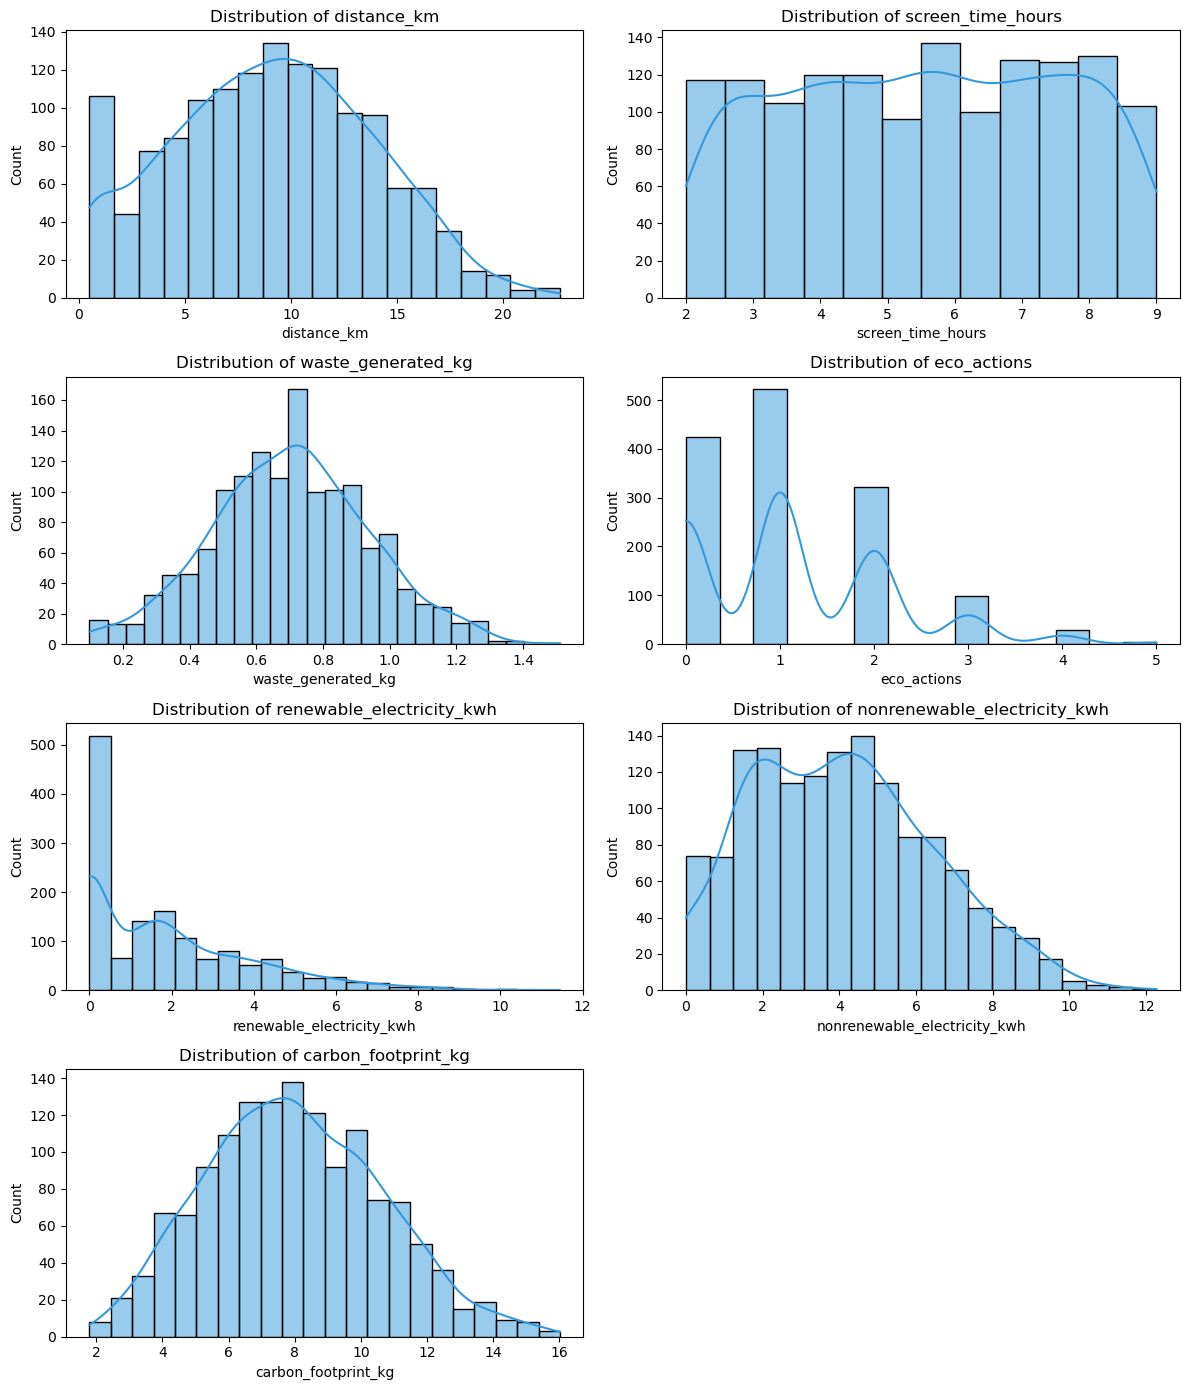

In [82]:
num_cols = ['distance_km', 'screen_time_hours', 'waste_generated_kg',
            'eco_actions', 'renewable_electricity_kwh', 'nonrenewable_electricity_kwh',
            'carbon_footprint_kg']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#3498db')
    axes[i].set_title('Distribution of ' + col)
    axes[i].set_xlabel(col)

# hide the unused 8th subplot
axes[7].axis('off')

plt.tight_layout()
plt.show()

Description:
These histograms show how each numerical variable is spread out across the 1400 daily records. carbon_footprint_kg is bell-shaped and centred around 7-8 kg CO₂, with a longer tail toward higher values, which shows the fact that fewer days are in the High impact category (194 out of 1400) compared to Medium (869) and Low (337). renewable_electricity_kwh has a large spike at zero meaning a share of days run entirely on non renewable electricity while nonrenewable_electricity_kwh itself is more evenly spread with a right-skew, most days fall between 1 to 7 kWh of non renewable use. eco_actions is gathered at low counts which are 0 to 2 actions per day, showing that most individuals take very few eco friendly actions daily which limits how much we can use these variable on its own to explain low carbon days. Both distance_km and screen_time_hours are evenly spread without extreme skew showing a mix of commuting distances and screen habits across the sample.

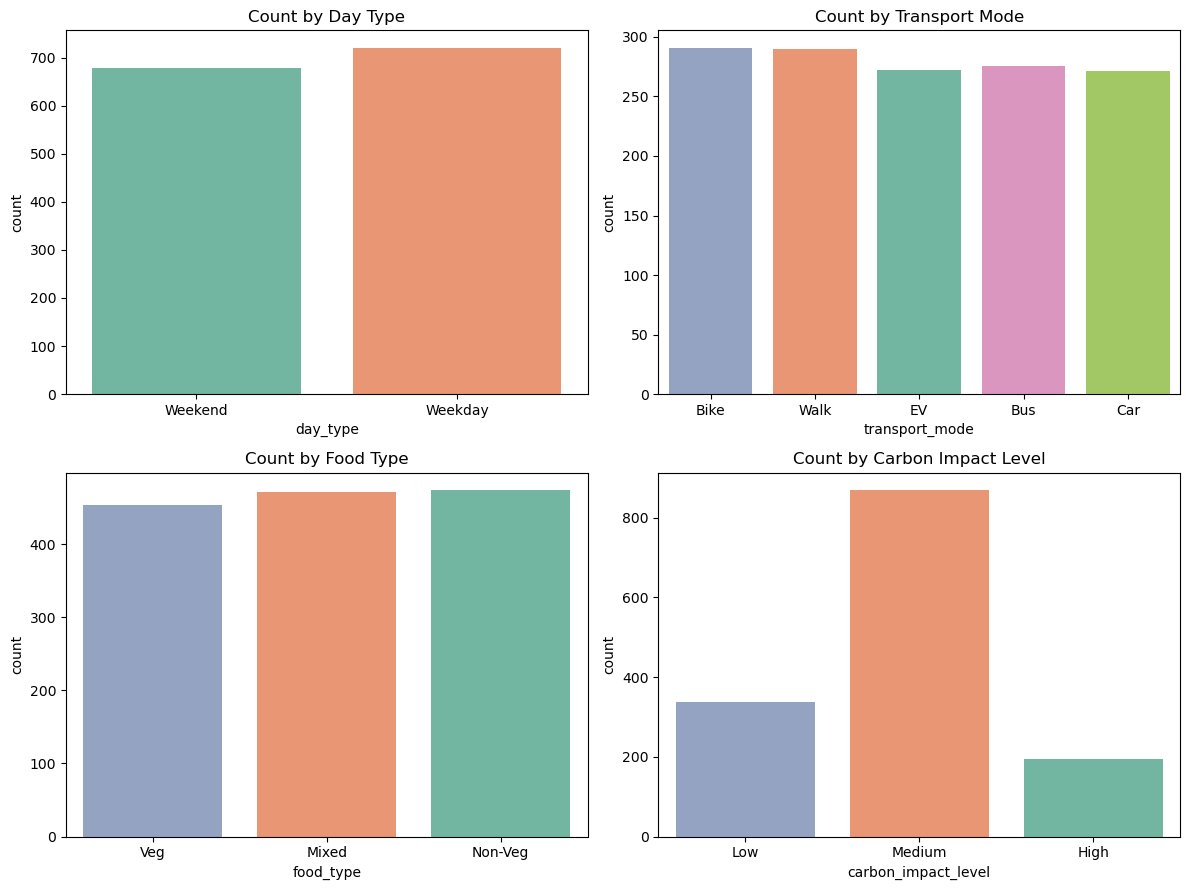

In [83]:
# transport_mode and food_type are already encoded to numbers from Section 4,
# map back to labels here only for readable plotting
transport_labels = {0: 'Bike', 1: 'Walk', 2: 'EV', 3: 'Bus', 4: 'Car'}
food_labels = {0: 'Veg', 1: 'Mixed', 2: 'Non-Veg'}

plot_df = df.copy()
plot_df['transport_mode_label'] = plot_df['transport_mode'].map(transport_labels)
plot_df['food_type_label'] = plot_df['food_type'].map(food_labels)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.countplot(data=plot_df, x='day_type', ax=axes[0, 0],
              palette='Set2', hue='day_type')
axes[0, 0].set_title('Count by Day Type')

sns.countplot(data=plot_df, x='transport_mode_label',
              order=['Bike', 'Walk', 'EV', 'Bus', 'Car'], ax=axes[0, 1],
              palette='Set2', hue="transport_mode_label")
axes[0, 1].set_title('Count by Transport Mode')
axes[0, 1].set_xlabel('transport_mode')

sns.countplot(data=plot_df, x='food_type_label',
              order=['Veg', 'Mixed', 'Non-Veg'], ax=axes[1, 0],
              palette='Set2', hue="food_type_label")
axes[1, 0].set_title('Count by Food Type')
axes[1, 0].set_xlabel('food_type')

sns.countplot(data=plot_df, x='carbon_impact_level',
              order=['Low', 'Medium', 'High'], ax=axes[1, 1],
              palette='Set2', hue="carbon_impact_level")
axes[1, 1].set_title('Count by Carbon Impact Level')

plt.tight_layout()
plt.show()

**Description:**  
The categorical counts show the dataset is reasonably balanced across `day_type` 721 weekday vs. 679 weekend records, `transport_mode` around 270-290 records per mode, so no single mode dominates the sample and `food_type` (Veg, Mixed, and Non-Veg) are each roughly a third of the data. This is good for analysis because it means later comparisons between groups like Car users vs Bike users are not
transport_labels = {0: 'Bike', 1: 'Walk', 2: 'EV', 3: 'Bus', 4: 'Car'}
food_labels = {0: 'Veg', 1: 'Mixed', 2: 'Non-Veg'}

plot_df = df.copy()
plot_df['transport_mode_label'] = plot_df['transport_mode'].map(transport_labels)
plot_df['food_type_label'] = plot_df['food_type'].map(food_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order_t = plot_df.groupby('transport_mode_label')['carbon_footprint_kg'].mean().sort_values(ascending=False).index
sns.barplot(data=plot_df, x='transport_mode_label', y='carbon_footprint_kg', order=order_t,
            ax=axes[0], palette='Reds_r', errorbar=None)
axes[0].set_title('Average Carbon Footprint by Transport Mode')
axes[0].set_xlabel('Transport Mode')
axes[0].set_ylabel('Carbon Footprint (kg CO2e)')

order_f = plot_df.groupby('food_type_label')['carbon_footprint_kg'].mean().sort_values(ascending=False).index
sns.barplot(data=plot_df, x='food_type_label', y='carbon_footprint_kg', order=order_f,
            ax=axes[1], palette='Oranges_r', errorbar=None)
axes[1].set_title('Average Carbon Footprint by Food Type')
axes[1].set_xlabel('Food Type')
axes[1].set_ylabel('Carbon Footprint (kg CO2e)')

plt.tight_layout()
plt.show() one sided by one group having far more records than the other. The one variable that is not balanced is `carbon_impact_level` where Medium dominates with 869 records (62%), while High impact days at 194 records (14%). This class imbalance we take a look into for later when explaining the classification models in Modelling section since a model can score a high accuracy just by being good at predicting the majority Medium class.

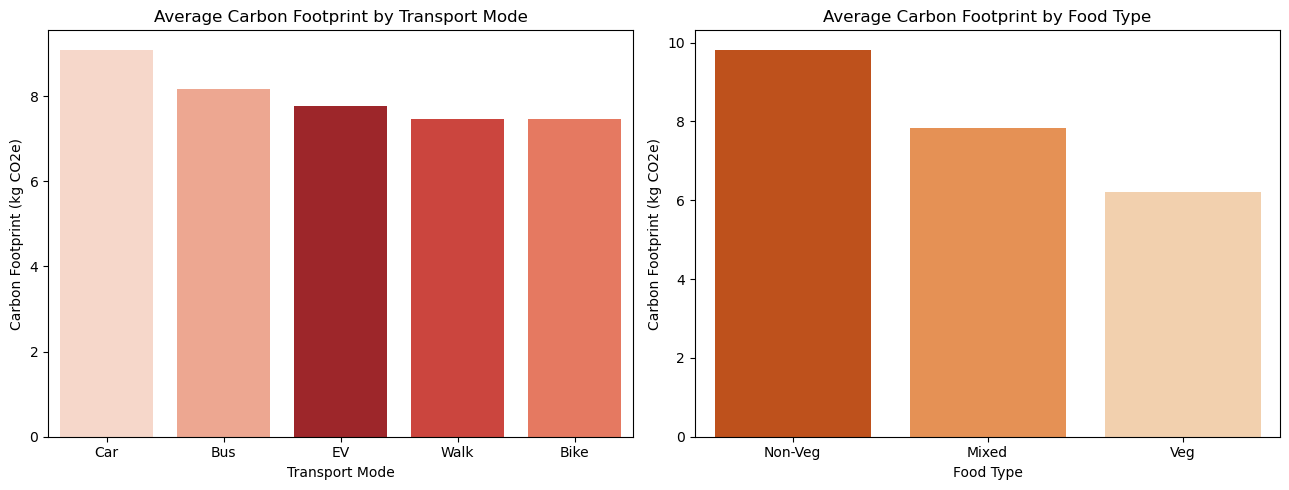

In [84]:
transport_labels = {0: 'Bike', 1: 'Walk', 2: 'EV', 3: 'Bus', 4: 'Car'}
food_labels = {0: 'Veg', 1: 'Mixed', 2: 'Non-Veg'}

plot_df = df.copy()
plot_df['transport_mode_label'] = plot_df['transport_mode'].map(transport_labels)
plot_df['food_type_label'] = plot_df['food_type'].map(food_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order_t = plot_df.groupby('transport_mode_label')['carbon_footprint_kg'].mean().sort_values(ascending=False).index
sns.barplot(data=plot_df, x='transport_mode_label', y='carbon_footprint_kg', order=order_t,
            ax=axes[0], palette='Reds_r', hue='transport_mode_label', errorbar=None)
axes[0].set_title('Average Carbon Footprint by Transport Mode')
axes[0].set_xlabel('Transport Mode')
axes[0].set_ylabel('Carbon Footprint (kg CO2e)')

order_f = plot_df.groupby('food_type_label')['carbon_footprint_kg'].mean().sort_values(ascending=False).index
sns.barplot(data=plot_df, x='food_type_label', y='carbon_footprint_kg', order=order_f,
            ax=axes[1], palette='Oranges_r', hue="food_type_label", errorbar=None)
axes[1].set_title('Average Carbon Footprint by Food Type')
axes[1].set_xlabel('Food Type')
axes[1].set_ylabel('Carbon Footprint (kg CO2e)')

plt.tight_layout()
plt.show()

**Description:**  
 We can observe that car users have the highest average for carbon footprint which is near 9,1kg CO2e per day followed by Bus at 8.2 kg and Ev at 7.8kg, while users who walk and use Bike are at the lowest at 7.5kg and 7.4kg, from this we can observer that Motorised vehicle that uses fuel like petrol and diesel produces the most carbon waste and the least eco frienly option while options like Ev Walking And Bike are the most eco friendly option. For food type, Non-Veg has a clearly higher average footprint (9.8 kg) than Mixed (7.8 kg) and Veg (6.2 kg), confirming that diet composition is one of the stronger behavioural drivers of an individual's daily footprint, consistent with existing literature on food-related emissions (Ritchie, 2023).

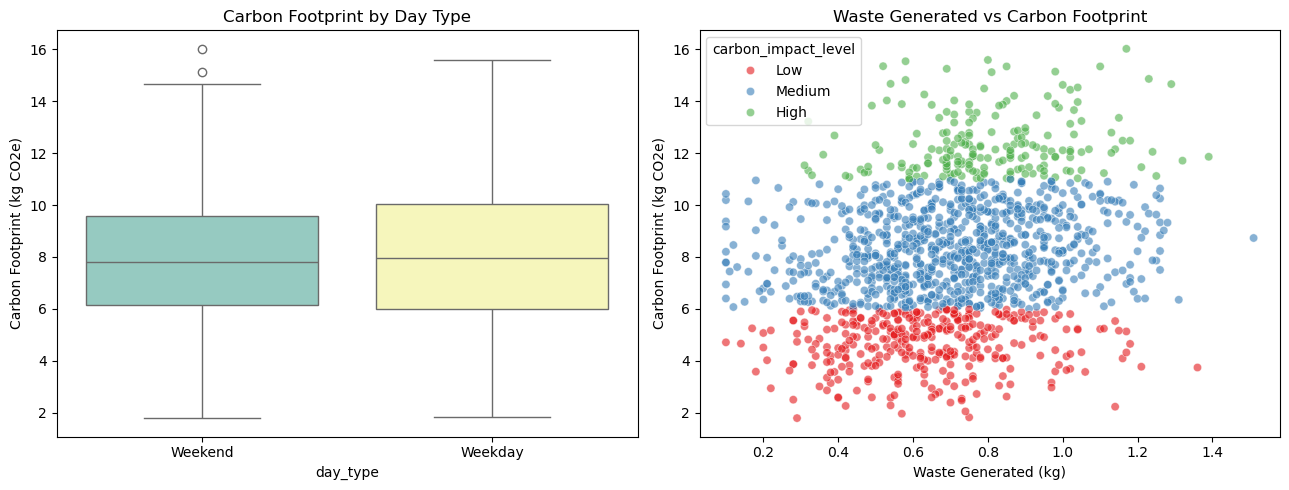

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='day_type', y='carbon_footprint_kg', ax=axes[0], palette='Set3', hue="day_type")
axes[0].set_title('Carbon Footprint by Day Type')
axes[0].set_ylabel('Carbon Footprint (kg CO2e)')

sns.scatterplot(data=df, x='waste_generated_kg', y='carbon_footprint_kg',
                hue='carbon_impact_level', hue_order=['Low', 'Medium', 'High'],
                palette='Set1', alpha=0.6, ax=axes[1])
axes[1].set_title('Waste Generated vs Carbon Footprint')
axes[1].set_xlabel('Waste Generated (kg)')
axes[1].set_ylabel('Carbon Footprint (kg CO2e)')

plt.tight_layout()
plt.show()

**Description:** 

We can observe that  the boxplot shows weekdays have abit higher median and mean carbon footprint compared to weekends which is 8.10kg vs 7.85 kg on average, but the two distribution overlap heavily, so the variable day_type is a weak predictor of footprint. it likely interacts with transport mode rahter than driving emissions directly.
Other than that, we can observe the scatter plot shows a positive relationship between variable waste_generated_kg and variable carbon_footprint_kg because points change from the Low impact (red) cluster, through Medium (blue), toward the High impact cluster (green) as waste increases, but the spread is wide, meaning waste alone does not cleanly separate the three impact levels.

### 5.2 Bivariate Relationships
 How the behavioural variables relate to `carbon_footprint_kg` individually. 

### 5.3 Correlation Matrix

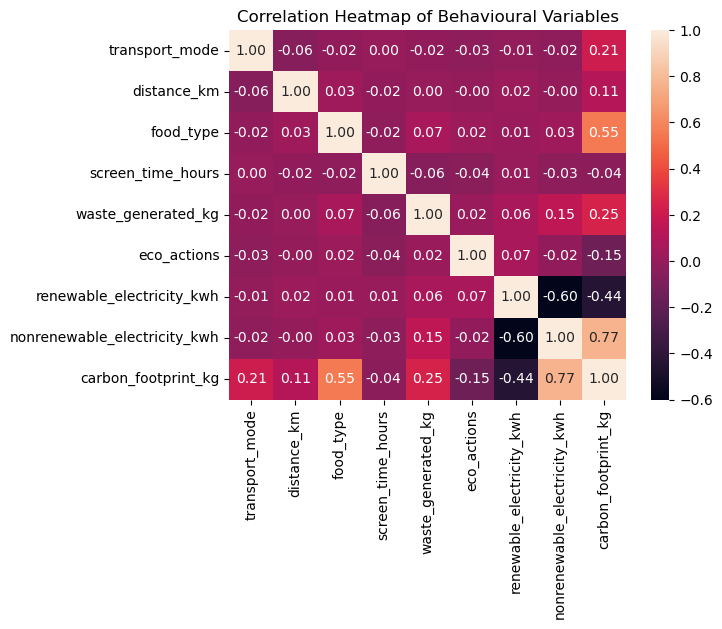

In [86]:
sns.heatmap(
    df[['transport_mode', 'distance_km', 'food_type',
        'screen_time_hours', 'waste_generated_kg', 'eco_actions',
        'renewable_electricity_kwh', 'nonrenewable_electricity_kwh',
        'carbon_footprint_kg']].corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap of Behavioural Variables')
plt.show()

The heatmap above showed the correlation between variable, our focus is variables that affect carbon footprint.

The main factor that positively correlate to carbon is:
- electricity_kwh
- waste_generated
- distance, required further studies between traversal type.  

The main factor that negatively correlate to carbon is:
- renewable_usage_pct
- eco_actions
- screen_time_hours, (odd, does not align)

**Description:**  
We can observe that heatmap shows pairwise correlation between each behavioral variable and (carbon_footprint_kg), (nonrenewable_electricity_kwh) has the strongest correlation (r = 0.77), its shows that its the strongest factor in the dataset followed by (food_type) (r = 0.55). We can also observe that (renewable_electricity_kwh) is the strongest negative correlation r = -0.44 this shows that more the person's electricity comes from renewable resources the lower their footprint is.

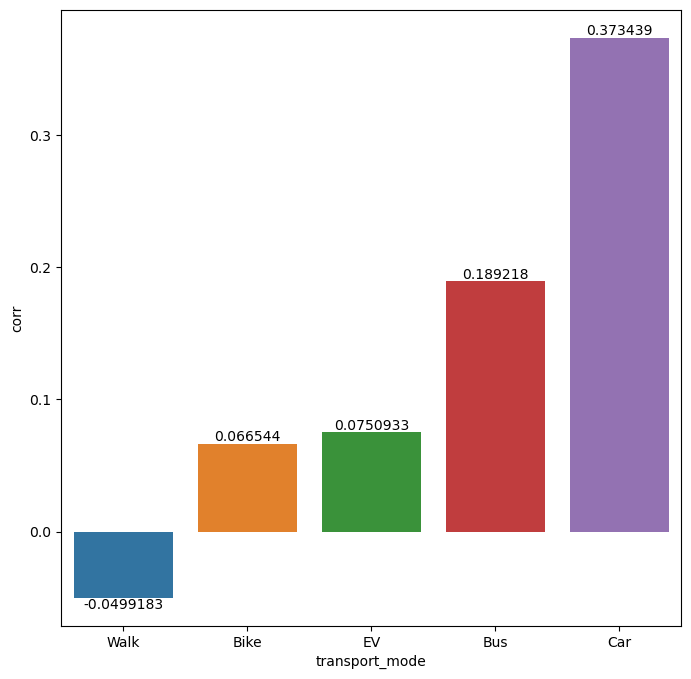

In [87]:
subcor = pd.DataFrame()
subcor["transport_mode"] = df['transport_mode'].unique()

for mode in df['transport_mode'].unique():
    subset = df[df['transport_mode'] == mode]
    subcor.loc[subcor["transport_mode"] == mode, "corr"] = subset['distance_km'].corr(subset['carbon_footprint_kg'])

subcor["transport_mode"] = subcor["transport_mode"].map(
    {0: 'Bike', 1: 'Walk', 2: 'EV', 3: 'Bus', 4: 'Car'})
subcor = subcor.set_index("transport_mode")

plt.figure(figsize=(8, 8))
ax = sns.barplot(subcor.sort_values(by="corr"),
                 x="transport_mode", y="corr",
                 hue="transport_mode", legend=False)

for i in range(5):
    ax.bar_label(ax.containers[i], fontsize=10)

*Description:**  
what this bar chart shows is the correlation between (distance_km) and (carbon_footprint_kg) for each transport mode seperately, We can observer that (Walk) has no relationship at corr = -0.05, shows that walking doesnt affect carbon footprint that much since it produces zero emissions, (Bike) and (EV) have weak correlation at 0.07 and 0.08, while bus is moderate at corr = 0.19 and Car has the strongest correlation at corr = 0.37.This tells us that distance traveled matters far more for footprint when the mode is (Car) every extra kilometre driven adds  more carbon than the same extra kilometre walked, biked, or taken by EV. This supports our earlier finding that (Car) is the most carbon-intensive transport mode.




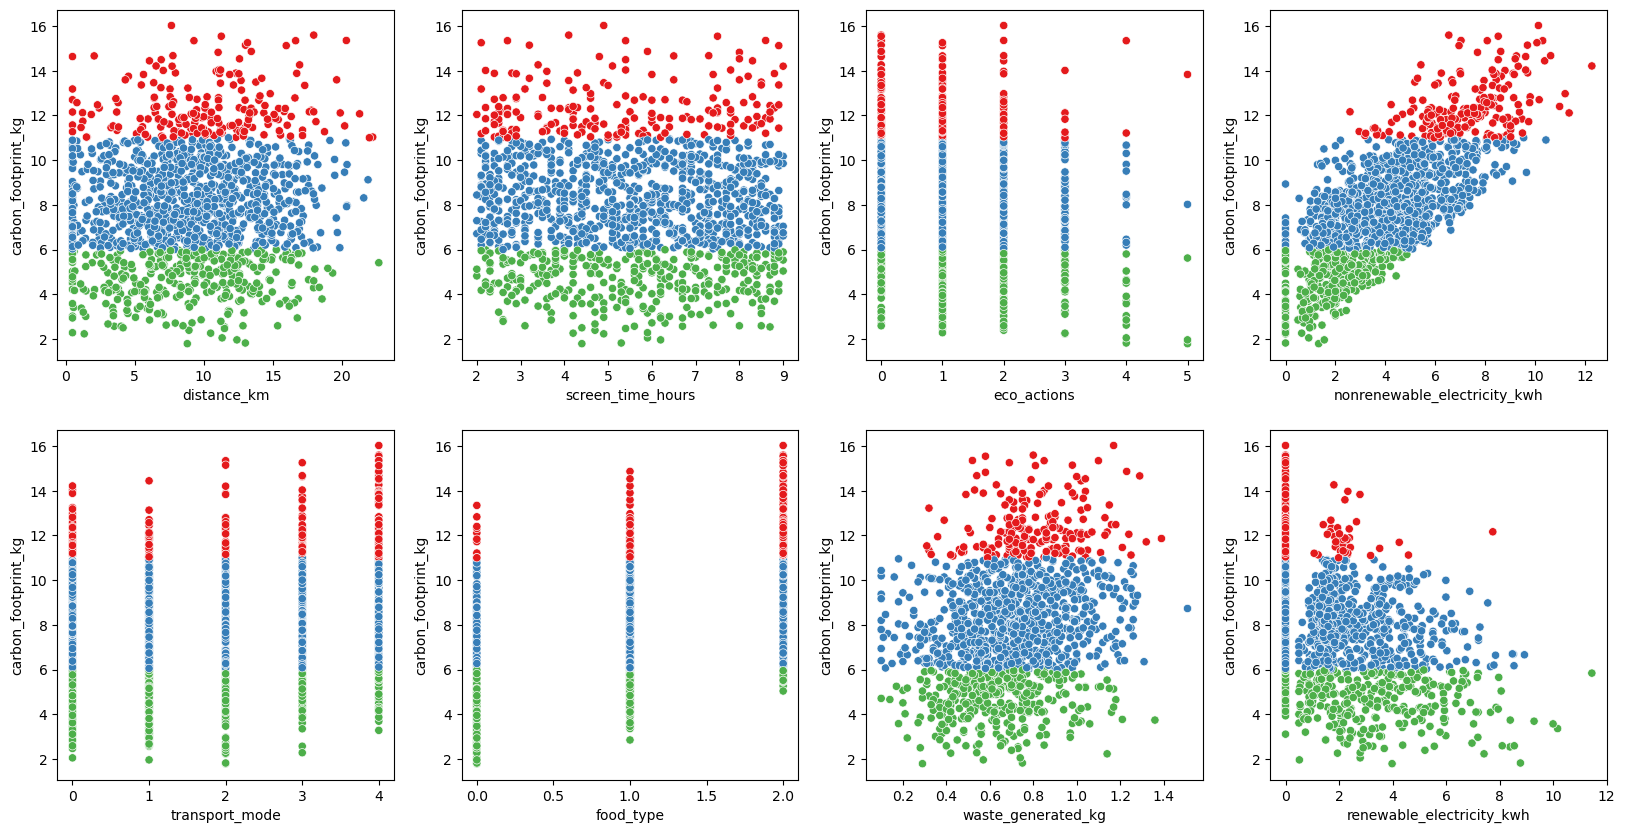

In [88]:
x_vars = ['transport_mode', 'distance_km', 'food_type', 'screen_time_hours',
          'waste_generated_kg', 'eco_actions', 'renewable_electricity_kwh', 'nonrenewable_electricity_kwh']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, var in enumerate(x_vars):
    row = i % 2 - 1
    col = math.floor(i/2)
    sns.scatterplot(data=df, x=var, y='carbon_footprint_kg',
                    palette="Set1", hue="carbon_impact_level",
                    ax=axes[row][col], legend=False)
    #axes[row][col].set_title(var)


plt.show()

**Description:** 

We can observe that panel above plots one behavioral variable against (carbon_footprint_kg) with points coloured by their assigned (carbon_impact_level) (red = Low, blue = Medium, green = High). But we can see that two panels stand out which are (food_type) and (nonrenewable_electricity_kwh) front he both plots we can see a clear left to right separation of colours,the High impact (green) points sit consistently at higher values of these two variables, while Low impact (red) points cluster at the lower end.This shows what the correlation heatmap already suggested, these two variables carry the most information for differentiating impact levels. Lastly, the plots for (eco_actions) and (screen_time_hours) show heavily overlapping colours across the full range of x-values, meaning these variables alone do not separate the impact groups well. This gives us a preview, going into Modelling, of which features the classification models are likely to rely on most heavily.

## 6. Modeling / Deeper Analysis (if applicable)
- Define task (prediction, classification, clustering, inference, etc.)
- Train/test split or cross-validation
- Baselines, metrics, and parameter choices
- Control randomness with fixed seeds


In [89]:
X = df[['transport_mode', 'distance_km', 'food_type',
        'screen_time_hours', 'waste_generated_kg', 'eco_actions',
        'renewable_electricity_kwh', 'nonrenewable_electricity_kwh']]
y = df['carbon_footprint_kg']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [90]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1120, 8)
(1120,)
(280, 8)
(280,)


In [91]:
some_data = X_test.iloc[:5]    # take first 5 entries from X_test
actual_carbon_values = y_test.iloc[:5].values     # here's the first 5 entries from y_test, which are the 'ground truth'
actual_carbon_values

array([ 5.56, 10.3 ,  9.03,  3.8 ,  4.85])

### Test cluster

In [92]:
user_profile = df.groupby('user_id').agg(
    avg_transport=('transport_mode', 'mean'),
    avg_distance=('distance_km', 'mean'),
    avg_nonrenewable_electricity=('nonrenewable_electricity_kwh', 'mean'),
    avg_renewable_electricity=('renewable_electricity_kwh', 'mean'),
    avg_screen_time=('screen_time_hours', 'mean'),
    avg_waste=('waste_generated_kg', 'mean'),
    avg_eco_actions=('eco_actions', 'mean'),
    avg_carbon=('carbon_footprint_kg', 'mean')
)

cluster_features = [c for c in user_profile.columns if c != 'avg_carbon']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(user_profile[cluster_features])
print(f"User profiles: {user_profile.shape}, Features: {len(cluster_features)}")

User profiles: (200, 8), Features: 7


In [93]:
user_profile

,avg_transport,avg_distance,avg_nonrenewable_electricity,avg_renewable_electricity,avg_screen_time,avg_waste,avg_eco_actions,avg_carbon
user_id,,,,,,,,
1,1.142857,6.514286,4.350714,1.490714,4.100000,0.614286,0.571429,7.700000
2,2.142857,7.075714,4.887143,2.151429,5.400000,0.840000,1.428571,9.375714
3,1.142857,10.811429,6.621071,1.093214,4.800000,0.827143,1.000000,8.977143
4,1.428571,12.251429,3.022143,1.995000,6.285714,0.754286,1.571429,6.714286
5,2.714286,11.170000,2.338571,4.847143,7.271429,0.797143,1.142857,8.367143
...,...,...,...,...,...,...,...,...
196,1.428571,10.635714,4.067857,1.026429,4.771429,0.678571,1.714286,8.561429
197,2.857143,8.112857,5.900000,0.781429,6.157143,0.734286,1.857143,9.305714
198,2.285714,9.695714,3.342857,1.704286,5.985714,0.555714,0.571429,6.702857


c:\Users\naves\anaconda3\envs\dsf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\naves\anaconda3\envs\dsf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\naves\anaconda3\envs\dsf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\naves\anaconda3\envs\dsf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is k

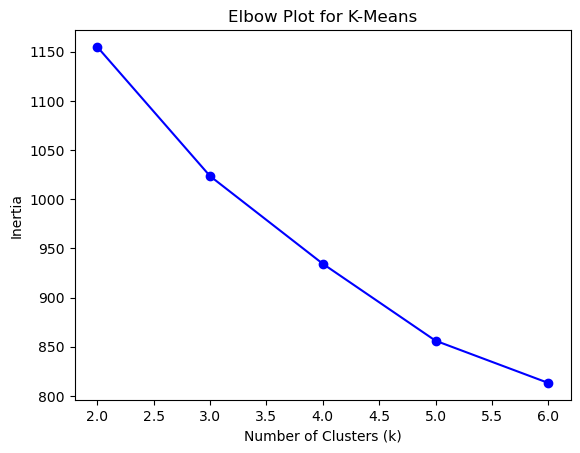

In [94]:
inertia_list = []
k_range = range(2, 7)
for k in k_range:
    model_k = KMeans(k, verbose=0, n_init='auto', random_state=42)
    model_k.fit(X_scaled)
    inertia_list.append(model_k.inertia_)

plt.plot(list(k_range), inertia_list, "bo-")
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot for K-Means')
plt.show()

In [95]:
model_km = KMeans(3, verbose=0, n_init='auto', random_state=42)
silhouette_score(X_scaled, model_km.fit_predict(X_scaled))

c:\Users\naves\anaconda3\envs\dsf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


0.15421398205812514

In [96]:
print("eps | clusters | noise | silhouette")
print("-" * 45)
for eps in [0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 4.0]:
    db, labels = dbscan(X_scaled, eps=eps)
    n_clusters = len(set(labels) - {-1})
    n_noise = list(labels).count(-1)
    sil = silhouette_score(X_scaled, labels) if n_clusters >= 2 else -1
    print(f"{eps:.1f}   | {n_clusters:3d}     | {n_noise:3d}   | {sil:.3f}")

eps | clusters | noise | silhouette
---------------------------------------------
0.3   |   0     | 200   | -1.000
0.5   |   0     | 200   | -1.000
0.8   |   0     | 200   | -1.000
1.0   |   0     | 200   | -1.000
1.5   |   4     | 134   | -0.139
2.0   |   1     |  16   | -1.000
3.0   |   1     |   0   | -1.000
4.0   |   1     |   0   | -1.000


In [97]:
sd_cluster = ['transport_mode', 'distance_km', 'food_type',
              'screen_time_hours', 'waste_generated_kg', 'eco_actions',
              'renewable_electricity_kwh', 'nonrenewable_electricity_kwh']

results = []
for feat in sd_cluster:
    X_1d = df[[feat]].values
    X_scaled_1d = StandardScaler().fit_transform(X_1d)
    db, labels = dbscan(X_scaled_1d, eps=1.5, min_samples=5)
    n_clusters = len(set(labels) - {-1})
    n_noise = list(labels).count(-1)
    sil = silhouette_score(X_scaled_1d, labels) if n_clusters >= 2 else -1
    results.append({'feature': feat, 'clusters': n_clusters, 'noise': n_noise, 'silhouette': sil})

db_c = pd.DataFrame(results)
db_c

,feature,clusters,noise,silhouette
0,transport_mode,1,0,-1
1,distance_km,1,0,-1
2,food_type,1,0,-1
3,screen_time_hours,1,0,-1
4,waste_generated_kg,1,0,-1
5,eco_actions,1,0,-1
6,renewable_electricity_kwh,1,0,-1
7,nonrenewable_electricity_kwh,1,0,-1


### 6.1 Rgr
#### 6.1.1 Linear Regression

In [98]:
reg = LinearRegression().fit(X_train, y_train)

In [99]:
reg.coef_

array([ 0.43559706,  0.06503266,  1.72930534, -0.00587994,  1.22596738,
       -0.39315734, -0.00919853,  0.81442577])

In [100]:
reg.score(X_test, y_test)

0.9702354538203902

In [101]:
reg.intercept_

np.float64(1.0971678558847282)

In [102]:
reg_carbon_values = reg.predict(some_data)
reg_carbon_values

array([ 5.257756  , 10.56172028,  8.91611407,  3.54455619,  5.01719032])

#### 6.1.2 Validation

In [103]:
r2_score(actual_carbon_values, reg_carbon_values)

0.9915603633527573

In [104]:
mean_absolute_error(actual_carbon_values, reg_carbon_values)

0.220096867410499

#### 6.1.3 Cross-Validation

In [105]:
cv_results = cross_validate(reg, X, y, cv=3, return_train_score=False)
cv_results.keys()

dict_keys(['fit_time', 'score_time', 'test_score'])

In [106]:
cv_results['test_score']

array([0.96590569, 0.97163373, 0.96380366])

In [107]:
cv_results['test_score'].mean()

np.float64(0.9671143582247081)

In [108]:
mae_scorer = make_scorer(mean_absolute_error)
cv_results = cross_validate(reg, X, y, cv=3, scoring=mae_scorer, return_train_score=False)
print(cv_results['test_score'])
cv_results['test_score'].mean()

[0.37687326 0.35024454 0.37127622]


np.float64(0.36613133840279083)

#### 6.2.1 Tree

In [109]:
dtr_p_mae = []
for param in range(20):  # (0 -> 19) + 1
    dtr_p = DecisionTreeRegressor(max_depth=param+1)
    dtr_p.fit(X_train, y_train)
    y_pred_p = dtr_p.predict(X_test)
    dtr_p_mae.append(mean_absolute_error(y_test, y_pred_p))
print(dtr_p_mae)

[1.76151512849302, 1.4059268101872944, 1.0539365193261039, 0.8985602816711963, 0.771580567745394, 0.6750016139540309, 0.6605570806395069, 0.6250695227658856, 0.614829858706227, 0.605941977251527, 0.5822043586373943, 0.6135753759398497, 0.6022748299319728, 0.6311696428571429, 0.6109107142857143, 0.6179107142857144, 0.6230714285714286, 0.602857142857143, 0.6153571428571429, 0.6050357142857143]


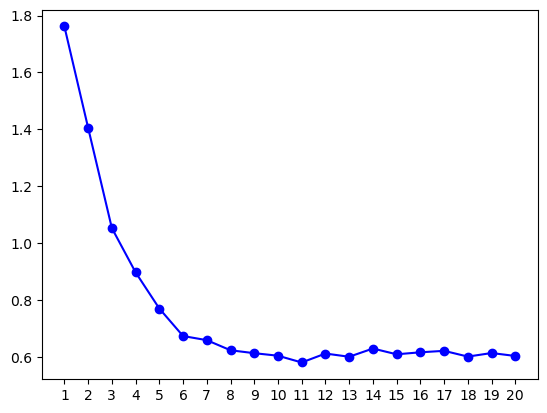

In [110]:
plt.plot(range(1, 21), dtr_p_mae, "bo-")
plt.xticks(range(1, 21))
plt.show()

**Description:** 

We can observer that thsi plot shows how Decision Tree Regressor's error MAE changes as we increase (max_depth) from 1 to 20,used to pick the best depth before fitting the final tree. Error drops from depth 1 (MAE ≈ 1.76 kg) down to about depth 9 to 10 (MAE ≈ 0.60 kg), after which it flattens out and barely improves, even fluctuating slightly, going deeper than 10, gives diminishing returns and risks overfitting. This is why (max_depth=10) was chosen for the final model below, it captures most of the achievable accuracy without needlessly growing a deeper, harder to interpret tree.



In [111]:
dtr = DecisionTreeRegressor(max_depth=10)
dtr.fit(X_train, y_train)
dtr_carbon_values = dtr.predict(X_test)

validate

In [112]:
mean_absolute_error(y_test, dtr_carbon_values)

0.5921065180678535

cross-validate

In [113]:
cv_results = cross_validate(dtr, X, y, cv=3, return_train_score=False)
cv_results.keys()

dict_keys(['fit_time', 'score_time', 'test_score'])

In [114]:
cv_results['test_score']

array([0.91674415, 0.91248654, 0.9112934 ])

In [115]:
cv_results['test_score'].mean()

np.float64(0.913508031328958)

In [116]:
mae_scorer = make_scorer(mean_absolute_error)
cv_results = cross_validate(dtr, X, y, cv=3, scoring=mae_scorer, return_train_score=False)
print(cv_results['test_score'])
cv_results['test_score'].mean()

[0.57254253 0.60320811 0.54275006]


np.float64(0.5728335673159731)

tree visual

Classification

In [117]:
X = df[['transport_mode', 'distance_km', 'food_type',
        'screen_time_hours', 'waste_generated_kg', 'eco_actions',
        'renewable_electricity_kwh', 'nonrenewable_electricity_kwh']]
y = df['carbon_impact_level']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [118]:
# Initialize models
log_reg = LogisticRegression(max_iter=200)
dec_tree = DecisionTreeClassifier(random_state=42)
rand_forest = RandomForestClassifier(random_state=42)

# Train models
log_reg.fit(X_train, y_train)
dec_tree.fit(X_train, y_train)
rand_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [119]:
models = {
    'Logistic Regression': log_reg,
    'Decision Tree': dec_tree,
    'Random Forest': rand_forest
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"{name}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))


Logistic Regression:
Accuracy: 0.92
              precision    recall  f1-score   support

        High       0.93      0.80      0.86        46
         Low       0.98      0.88      0.93        73
      Medium       0.90      0.98      0.93       161

    accuracy                           0.92       280
   macro avg       0.94      0.89      0.91       280
weighted avg       0.92      0.92      0.92       280

Decision Tree:
Accuracy: 0.89
              precision    recall  f1-score   support

        High       0.89      0.72      0.80        46
         Low       0.91      0.88      0.90        73
      Medium       0.87      0.94      0.90       161

    accuracy                           0.89       280
   macro avg       0.89      0.84      0.86       280
weighted avg       0.89      0.89      0.88       280

Random Forest:
Accuracy: 0.87
              precision    recall  f1-score   support

        High       0.94      0.72      0.81        46
         Low       0.90      0.78

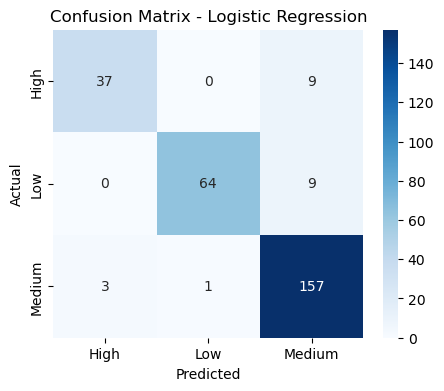

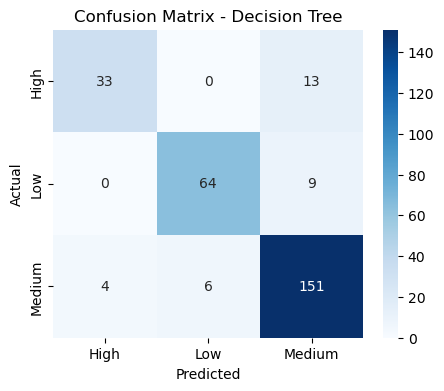

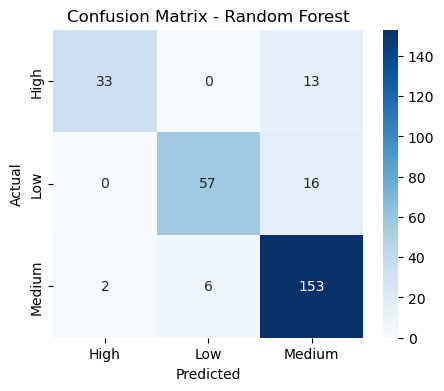

In [ ]:
class_labels = sorted(y_test.unique())  

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

**Description:**  
These confusion matrices show, for each model, how many test set days were correctly vs incorrectly classified into Low,Medium,High carbon impact level. All three models are very accurate at predicting Medium and make almost no mistakes between Low and High, the two classes are never confused with each other, only with Medium. The main weakness from three models is correctly catching every High day Logistic Regression correctly identifies 37 out of 46 High days, wrongly calssifying the other 9 as Medium, Decision Tree and Random Forest both do slightly worse, identifying 33 of 46 72% recall. This matches the class imbalance noted earlier in Section 5, since High is the smallest class 194 of 1400 records overall, the models have less data to learn its pattern from.


## 7. Performance Evaluation and Enhancement (if applicable)

In [121]:
X = df[['transport_mode', 'distance_km', 'food_type',
        'screen_time_hours', 'waste_generated_kg', 'eco_actions',
        'renewable_electricity_kwh', 'nonrenewable_electricity_kwh']]
y = df['carbon_footprint_kg']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [122]:
# Compare regression models
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1)': Ridge(alpha=1.0, random_state=42),
    'Ridge (alpha=10)': Ridge(alpha=10.0, random_state=42),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, random_state=42),
    'Decision Tree (depth=10)': DecisionTreeRegressor(max_depth=10, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
    })

results_df = pd.DataFrame(results).round(4)
print(results_df)

                      Model      R²     MAE
0         Linear Regression  0.9702  0.3604
1           Ridge (alpha=1)  0.9702  0.3604
2          Ridge (alpha=10)  0.9700  0.3629
3         Lasso (alpha=0.1)  0.9539  0.4601
4  Decision Tree (depth=10)  0.9187  0.5922


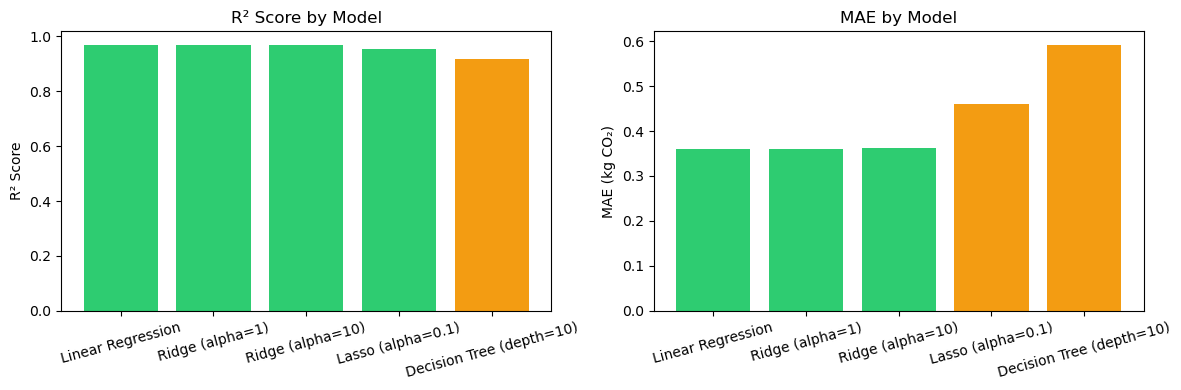

In [123]:
# Bar plot comparing regression models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R² plot (higher is better)
colors_r2 = ['#2ecc71' if v >= 0.95 else '#f39c12' if v >= 0.85 else '#e74c3c'
             for v in results_df['R²']]
axes[0].bar(results_df['Model'], results_df['R²'], color=colors_r2)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score by Model')
axes[0].tick_params(axis='x', rotation=15)

# MAE plot (lower is better)
colors_mae = ['#2ecc71' if v <= 0.4 else '#f39c12' if v <= 0.6 else '#e74c3c'
              for v in results_df['MAE']]
axes[1].bar(results_df['Model'], results_df['MAE'], color=colors_mae)
axes[1].set_ylabel('MAE (kg CO₂)')
axes[1].set_title('MAE by Model')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Description:**  
We can see that this chart compares 5 regression approaches for predicting (carbon_footprint_kg) which are Linear Regression, Ridge with two different regularization strengths, Lasso, and a Decision Tree depth=10.Linear Regression and Ridge alpha=1 are tied for the best result (R² = 0.97, MAE = 0.36 kg), Ridge with stronger regularization alpha=10 is almost identical (R² = 0.97), while Lasso (R² = 0.95) and the Decision Tree (R² = 0.92) both perform noticeably worse, with higher error (MAE 0.46 kg and 0.59 kg ). We can observe that adding regularization (Ridge/Lasso) or switching to a tree based model did not improve on plain Linear Regression here, in fact it slightly hurt performance, this shows the relationship between behaviour and carbon footprint in this dataset is close to linear, so a simple linear model is enough.

## 8. The FOUR Analytical Questions
- Answer each questions with supporting facts from the data analysis.
- Use visuals for clearer communication whenever possible. 


## 9. Results & Interpretation
- Summarize key findings
- Discuss insights generated from the data analysis and modeling
- Present the most informative visuals/tables with clear captions
- Relate results back to the research questions


## 10. Conclusions & Limitations
- What did you learn?
- What are limitations and possible biases?
- What are logical next steps or improvements?


## References
- Any academic articles, blogs, or documentation used
- All references in APA format only
- Citation in text example: The field of natural language processing has become dominated by deep learning approaches (Young et al., [2018](https://doi.org/10.1109/MCI.2018.2840738)).
- Citation example in the list:
    - [Python Docs](https://docs.python.org/3/)
    - [Python Tutorial](https://docs.python.org/3/tutorial/index.html)



1. Pandey, D., Agrawal, M., & Pandey, J. S. (2010). Carbon footprint: current methods of estimation. Environmental Monitoring and Assessment, 178(1–4), 135–160. https://doi.org/10.1007/s10661-010-1678-y
   <!--
   Parenthetical: (Pandey et al., 2010)
   Narrative    : Pandey et al. (2010)
   -->
2. Wongsaichia, S., Pienwisetkaew, T., Wannapipat, W., Ponsree, K., & Ketkaew, C. (2025). The influence of carbon perception on sustainable behaviors: Tailoring sustainability strategies based on individuals’ levels of openness to green technology adoption. Cleaner and Responsible Consumption, 17, 100270. https://doi.org/10.1016/j.clrc.2025.100270
   <!--
   Parenthetical: (Wongsaichia et al., 2025)
   Narrative    : Wongsaichia et al. (2025)
   -->
3. Malaysia’s Carbon Footprint - Malaysia Population Research Hub. (n.d.). Malaysia Population Research Hub. https://mprh.lppkn.gov.my/malaysias-carbon-footprint/
   <!--
   Parenthetical: (Malaysia’s Carbon Footprint - Malaysia Population Research Hub, n.d.)
   -->
4. Wikipedia contributors. (2026, April 26). Carbon footprint. Wikipedia. https://en.wikipedia.org/wiki/Carbon_footprint
   <!--
   Parenthetical: (Wikipedia contributors, 2026)
   -->
5. Ritchie, H. (2020, January 24). You want to reduce the carbon footprint of your food? Focus on what you eat, not whether your food is local. Our World in Data. https://ourworldindata.org/food-choice-vs-eating-local
   <!--
   Parenthetical: (Ritchie, 2020)
   Narrative    : Ritchie (2020)
   -->
6. Carbon dioxide emissions from electricity - World Nuclear Association. (n.d.). https://world-nuclear.org/information-library/energy-and-the-environment/carbon-dioxide-emissions-from-electricity
   <!--
   Parenthetical: (Carbon Dioxide Emissions From Electricity - World Nuclear Association, n.d.)
   -->
7. Ritchie, H. (2023, August 30). Which form of transport has the smallest carbon footprint? Our World in Data. https://ourworldindata.org/travel-carbon-footprint
   <!--
   Parenthetical: (Ritchie, 2023)
   Narrative    : Ritchie (2023)
   -->
8. United Nations. (n.d.). Food and Climate Change: Healthy diets for a healthier planet | United Nations. https://www.un.org/en/climatechange/science/climate-issues/food
   <!--
   Parenthetical: (United Nations, n.d.)
   -->
9. DeWeerdt, S., & DeWeerdt, S. (2024, October 25). What’s the carbon footprint of average Internet use? Anthropocene. https://www.anthropocenemagazine.org/2024/05/the-average-internet-user-spends-3230-hours-online-every-year-heres-the-carbon-footprint-of-that/
   <!--
   Parenthetical: (DeWeerdt & DeWeerdt, 2024)
   Narrative    : DeWeerdt and DeWeerdt (2024)
   -->
10. Hoa, P. X., Xuan, V. N., & Thu, N. T. P. (2024). Factors affecting carbon dioxide emissions for sustainable development goals – New insights into six asian developed countries. Heliyon, 10(21), e39943. https://doi.org/10.1016/j.heliyon.2024.e39943
   <!--
   Parenthetical: (Hoa et al., 2024)
   Narrative    : Hoa et al. (2024)
   -->
11. Hunt, K. (2022, October 4). How our trash contributes to climate change — and what we can do about it. Clean Air Task Force. https://www.catf.us/2022/09/how-our-trash-contributes-to-climate-change/
   <!--
   Parenthetical: (Hunt, 2022)
   Narrative    : Hunt (2022)
   -->
12. Hernandez, M. (2025, April 9). The most impactful things you can do for the climate aren’t what you’ve been told. World Resources Institute. https://www.wri.org/insights/climate-impact-behavior-shifts
   <!--
   Parenthetical: (Hernandez, 2025)
   Narrative    : Hernandez (2025)
   -->
13. Li, S., Wang, P., Liu, Q., & Liu, L. (2026). Reducing CO2 emissions from short-distance vehicle trips: A pathway to sustainable urban transport. Sustainable Cities and Society, 137, 107154. https://doi.org/10.1016/j.scs.2026.107154
   <!--
   Parenthetical: (Li et al., 2026)
   Narrative    : Li et al. (2026)
   -->

## Academic Integrity

- Work must be your own. If you use code snippets or ideas from references, cite them in the notebook.
- Do not include copyrighted data not permitted for redistribution.


## Plagiarism
It is fine to seek help from friends or from online resources when you do the assignment, However,
seeking help should not go overboard, to the point of getting (or even paying) someone to
complete the assignment partly or fully for you, copying from online resources without
understanding, or doing any means with the intention to cheat. 

For this assignment, plagiarism
means the following:
(a) Turning in a work that, from the examiner’s point of view, you do not sufficiently understand.
(b) Turning in someone else’s work (whether partly or fully) as your own.
(c) To use another’s work (whether partly or fully) without crediting the source.
(d) Any means of cheating.

**Plagiarism is a serious offence.**

**We will give ZERO (0) marks to students who plagiarize AND to students who intentionally or
unintentionally help other students to plagiarize by giving all or some of their code.**

## Final Self‑Checklist (before submitting)

* [ ] Rename your Jupyter Notebook file according to your group number
* [ ] All items in README section are filled up
* [ ] All group members' ID, name, and contribution fill-in.
* [ ] Dataset link is from a recognized source and publicly accessible
* [ ] YouTube link is accessible.
* [ ] Notebook runs end‑to‑end with no manual steps beyond placing data files
* [ ] Dataset loaded once only
* [ ] No absolute paths; only relative paths used
* [ ] All figures have titles/labels; text and tables are readable
* [ ] Methods and choices are explained and justified
* [ ] References properly cited
* [ ] Notebook is clear, professional, and run within reasonable runtime